# 02: Agent Performance

In [1]:
#imports and connection
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
from scipy import stats

PROJECT = "ae-project-portfolio"
DATASET = "marts"

client = bigquery.Client(project=PROJECT)

def query(sql):
    return client.query(sql).to_dataframe()

print("Connected!")

Connected!


## Agent Performance Overview

In [2]:
agent_summary = query(f"""
select
    agent_id,
    agent_first_name,
    agent_last_name,
    agent_level,
    assigned_team,
    sum(tickets_resolved) as total_resolved,
    round(avg(avg_csat_score), 2) as avg_csat,
    round(avg(sla_breach_rate), 1) as avg_breach_rate,
    round(avg(escalation_rate), 1) as avg_escalation_rate,
    round(avg(avg_resolution_hours), 1) as avg_resolution_hours
from `{PROJECT}.{DATASET}.fct_agent_performance`
group by 1, 2, 3, 4, 5
order by avg_csat desc
""")

print(f"Total agents: {len(agent_summary)}")
print(f"\nTop 10 agents by CSAT:")
print(agent_summary[['agent_first_name', 'agent_last_name',
                     'agent_level', 'assigned_team',
                     'avg_csat', 'avg_breach_rate',
                     'total_resolved']].head(10).to_string(index=False))

/opt/miniconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Total agents: 50

Top 10 agents by CSAT:
agent_first_name agent_last_name agent_level assigned_team  avg_csat  avg_breach_rate  total_resolved
          Debbie          Bryant         mid     technical      4.05              3.2             301
          Thomas         Calhoun      senior     technical      4.02              0.2             294
           Debra             Kim      senior     technical      3.98              0.3             307
         Crystal           Perez      junior       general      3.97              9.4             296
            Dale        Humphrey         mid       billing      3.96              3.1             257
          Joshua      Washington      senior   escalations      3.96              1.6             290
         Matthew         Chapman         mid       general      3.96              2.4             284
            John            Tran      senior       general      3.96              1.0             295
            John         Wheeler         

## Performance by agent level

/opt/miniconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Performance by Agent Level:
agent_level  agent_count  avg_csat  avg_breach_rate  avg_escalation_rate  avg_resolution_hours  avg_weekly_tickets
     junior           22      3.87              9.3                  6.5                  38.6                 2.2
        mid           20      3.92              3.6                  5.1                  27.7                 2.2
     senior            8      3.95              0.7                  5.3                  19.5                 2.2


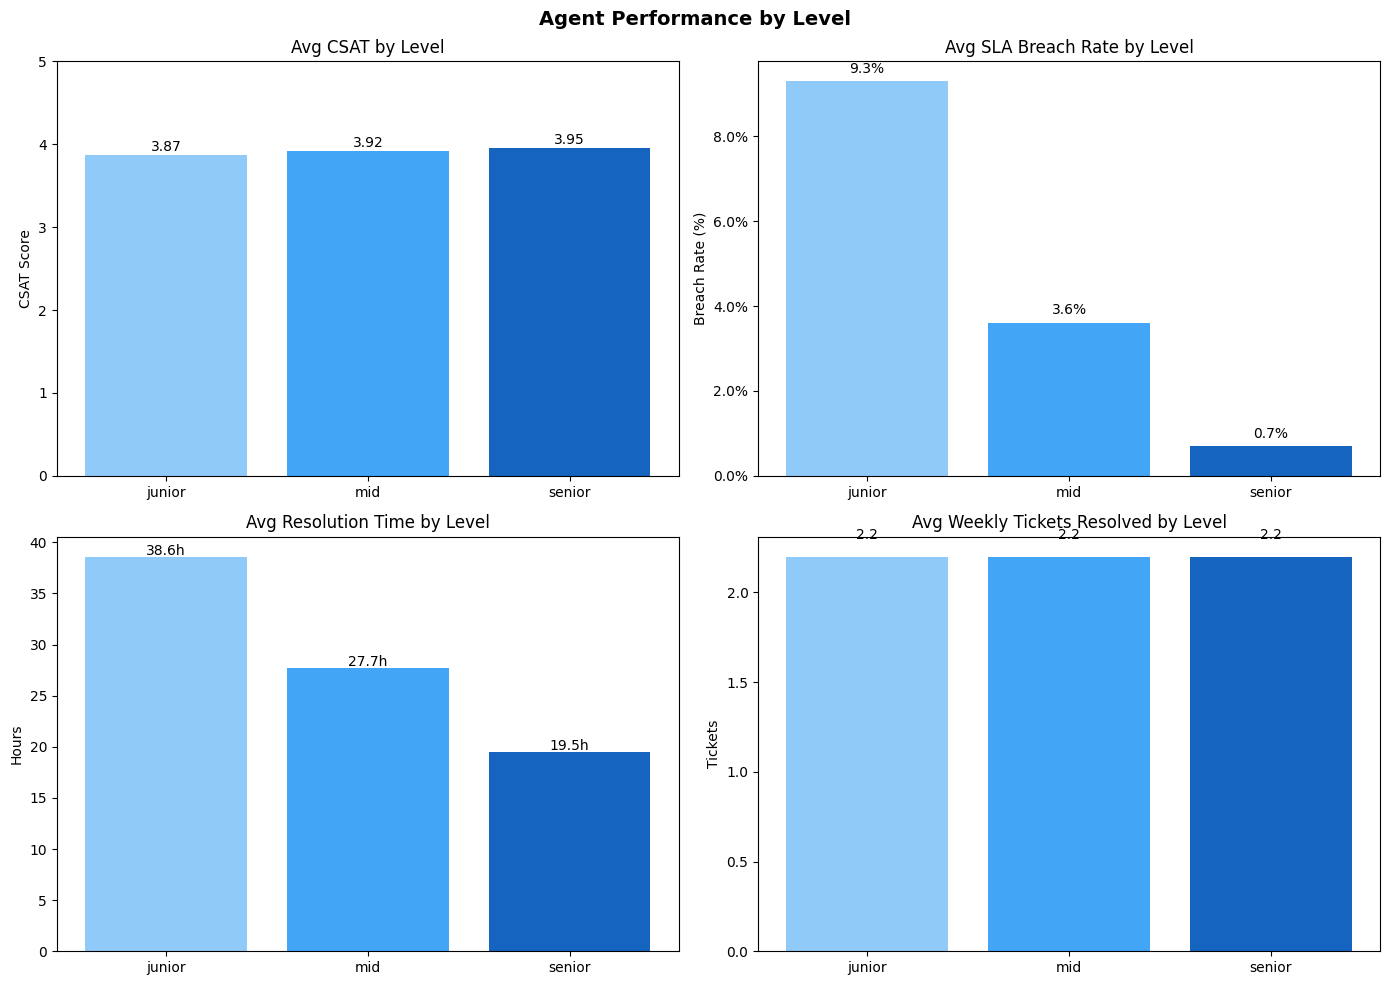

In [7]:
level_perf = query(f"""
select
    agent_level,
    count(distinct agent_id) as agent_count,
    round(avg(avg_csat_score), 2) avg_csat,
    round(avg(sla_breach_rate), 1) as avg_breach_rate,
    round(avg(escalation_rate), 1) as avg_escalation_rate,
    round(avg(avg_resolution_hours), 1) as avg_resolution_hours,
    round(avg(tickets_resolved), 1) as avg_weekly_tickets
from `{PROJECT}.{DATASET}.fct_agent_performance`
group by 1
order by 1
""")

print("Performance by Agent Level:")
print(level_perf.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Agent Performance by Level', fontsize=14, fontweight='bold')

level_order = ['junior', 'mid', 'senior']
df = level_perf.set_index('agent_level').reindex(level_order).reset_index()
colors =  ['#90CAF9', '#42A5F5', '#1565C0']

axes[0,0].bar(df['agent_level'], df['avg_csat'], color=colors)
axes[0,0].set_title('Avg CSAT by Level')
axes[0,0].set_ylabel('CSAT Score')
axes[0,0].set_ylim(0, 5)
for i, v in enumerate(df['avg_csat']):
    axes[0,0].text(i, v + 0.05, f'{v}', ha='center')

axes[0,1].bar(df['agent_level'], df['avg_breach_rate'], color=colors)
axes[0,1].set_title('Avg SLA Breach Rate by Level')
axes[0,1].set_ylabel('Breach Rate (%)')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i,v in enumerate(df['avg_breach_rate']):
    axes[0,1].text(i, v + 0.2, f'{v}%', ha='center')

axes[1,0].bar(df['agent_level'], df['avg_resolution_hours'], color=colors)
axes[1,0].set_title('Avg Resolution Time by Level')
axes[1,0].set_ylabel('Hours')
for i, v in enumerate(df['avg_resolution_hours']):
    axes[1,0].text(i, v + 0.2, f'{v}h', ha='center')

axes[1,1].bar(df['agent_level'], df['avg_weekly_tickets'], color=colors)
axes[1,1].set_title('Avg Weekly Tickets Resolved by Level')
axes[1,1].set_ylabel('Tickets')
for i,v in enumerate(df['avg_weekly_tickets']):
    axes[1,1].text(i,v + 0.1, f'{v}', ha='center')

plt.tight_layout()
plt.savefig('performance_by_level.png', dpi=150, bbox_inches='tight')
plt.show()

## Team Performance

/opt/miniconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Performance by Team:
assigned_team  agent_count  total_resolved  avg_csat  avg_breach_rate  avg_escalation_rate  avg_resolution_hours
  escalations           11            3265      3.91              4.9                  5.5                  30.1
    technical           20            6080      3.91              5.6                  6.1                  30.5
      general           13            3906      3.90              5.9                  5.6                  32.3
      billing            6            1739      3.87              6.9                  5.6                  33.6


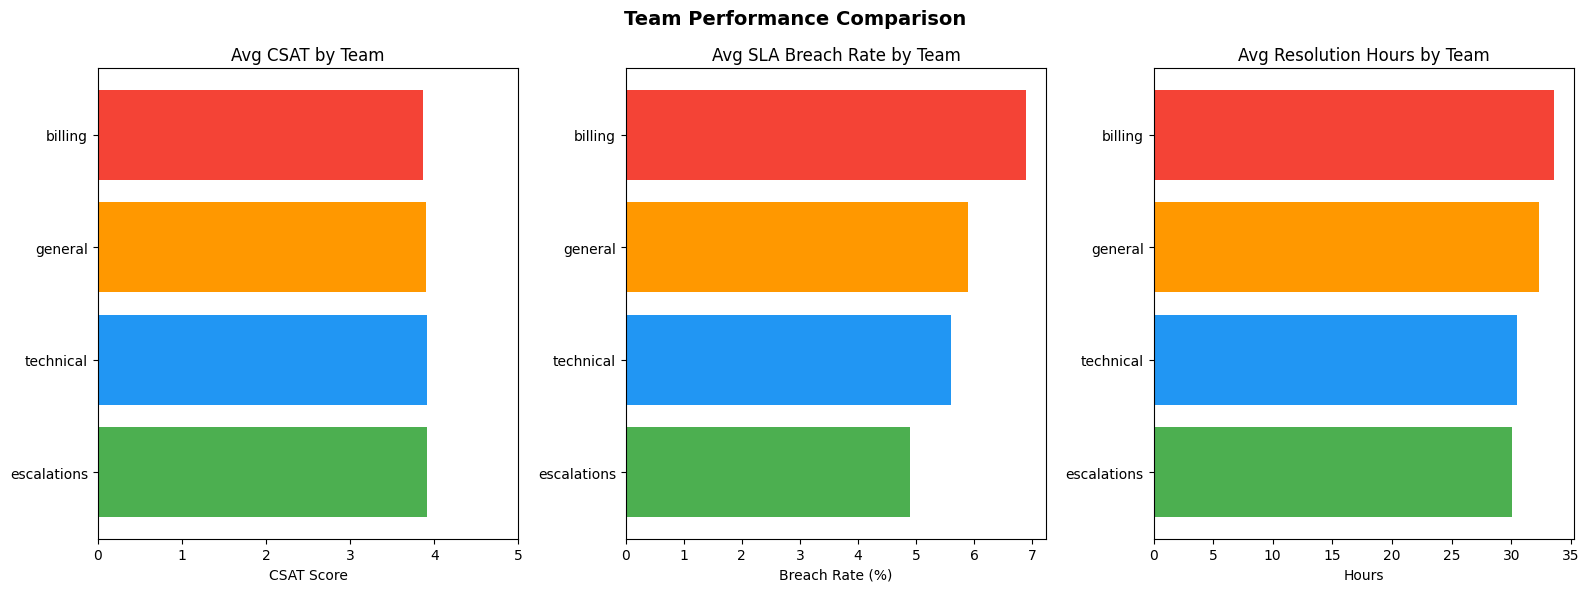

In [10]:
team_perf = query(f"""
select
    assigned_team,
    count(distinct agent_id) as agent_count,
    sum(tickets_resolved) as total_resolved,
    round(avg(avg_csat_score), 2) as avg_csat,
    round(avg(sla_breach_rate), 1) as avg_breach_rate,
    round(avg(escalation_rate), 1) as avg_escalation_rate,
    round(avg(avg_resolution_hours), 1) as avg_resolution_hours
from `{PROJECT}.{DATASET}.fct_agent_performance`
where assigned_team is not null
group by 1
order by avg_csat desc
""")

print("Performance by Team:")
print(team_perf.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16,6))
fig.suptitle('Team Performance Comparison', fontsize=14, fontweight='bold')

team_colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
df = team_perf.sort_values('avg_breach_rate', ascending=True)

axes[0].barh(df['assigned_team'], df['avg_csat'], color=team_colors)
axes[0].set_title('Avg CSAT by Team')
axes[0].set_xlabel('CSAT Score')
axes[0].set_xlim(0,5)

axes[1].barh(df['assigned_team'], df['avg_breach_rate'], color=team_colors)
axes[1].set_title('Avg SLA Breach Rate by Team')
axes[1].set_xlabel('Breach Rate (%)')

axes[2].barh(df['assigned_team'], df['avg_resolution_hours'], color=team_colors)
axes[2].set_title('Avg Resolution Hours by Team')
axes[2].set_xlabel('Hours')

plt.tight_layout()
plt.savefig('performance_by_team.png', dpi=150, bbox_inches='tight')
plt.show()

## Agent performance scatter - CSAT vs breach rate

/var/folders/8h/x0jbyn051fs3cqqsc0yx7k600000gn/T/ipykernel_81664/4176900198.py:39: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from current font.
  plt.tight_layout()
/var/folders/8h/x0jbyn051fs3cqqsc0yx7k600000gn/T/ipykernel_81664/4176900198.py:40: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from current font.
  plt.savefig('agent_performance_matrix.png', dpi=150, bbox_inches='tight')
/opt/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


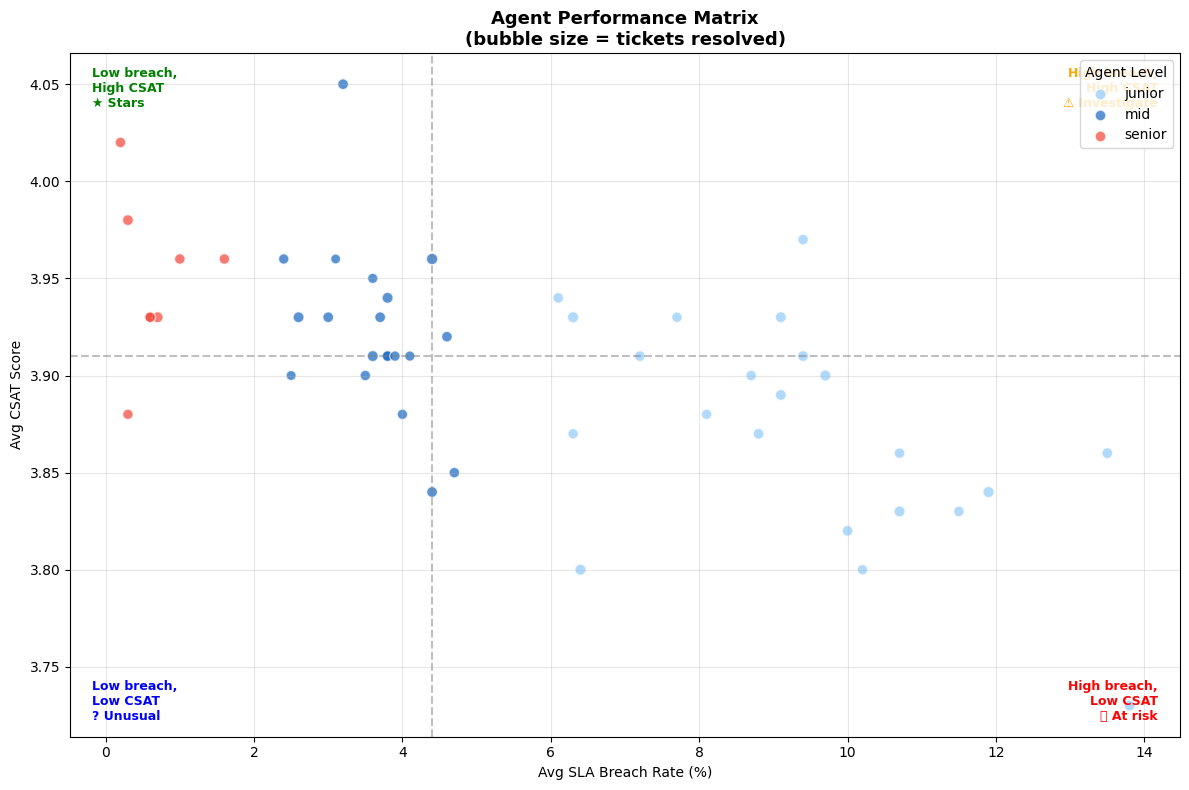

In [15]:
scatter_data = agent_summary.dropna(subset=['avg_csat', 'avg_breach_rate'])

fig, ax = plt.subplots(figsize=(12, 8))

level_colors = {'junior': '#90CAF9', 'mid': '#1565C0', 'senior': '#F44336'}
for level, group in scatter_data.groupby('agent_level'):
    ax.scatter(group['avg_breach_rate'], group['avg_csat'],
               c=level_colors[level], label=level,
               s=group['total_resolved'] /5,
               alpha=0.7, edgecolors='white')

#add quadrant lines
ax.axhline(y=scatter_data['avg_csat'].median(),
           color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=scatter_data['avg_breach_rate'].median(),
           color='gray', linestyle='--', alpha=0.5)

#label quadrants
ax.text(0.02, 0.98, 'Low breach,\nHigh CSAT\n★ Stars',
        transform=ax.transAxes, va='top', fontsize=9,
        color='green', fontweight='bold')
ax.text(0.98, 0.98, 'High breach,\nHigh CSAT\n⚠ Investigate',
        transform=ax.transAxes, va='top', ha='right',
        fontsize=9, color='orange', fontweight='bold')
ax.text(0.02, 0.02, 'Low breach,\nLow CSAT\n? Unusual',
        transform=ax.transAxes, va='bottom', fontsize=9,
        color='blue', fontweight='bold')
ax.text(0.98, 0.02, 'High breach,\nLow CSAT\n🚨 At risk',
        transform=ax.transAxes, va='bottom', ha='right',
        fontsize=9, color='red', fontweight='bold')

ax.set_title('Agent Performance Matrix\n(bubble size = tickets resolved)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Avg SLA Breach Rate (%)')
ax.set_ylabel('Avg CSAT Score')
ax.legend(title='Agent Level')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('agent_performance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Weekly Performance Trends

/opt/miniconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


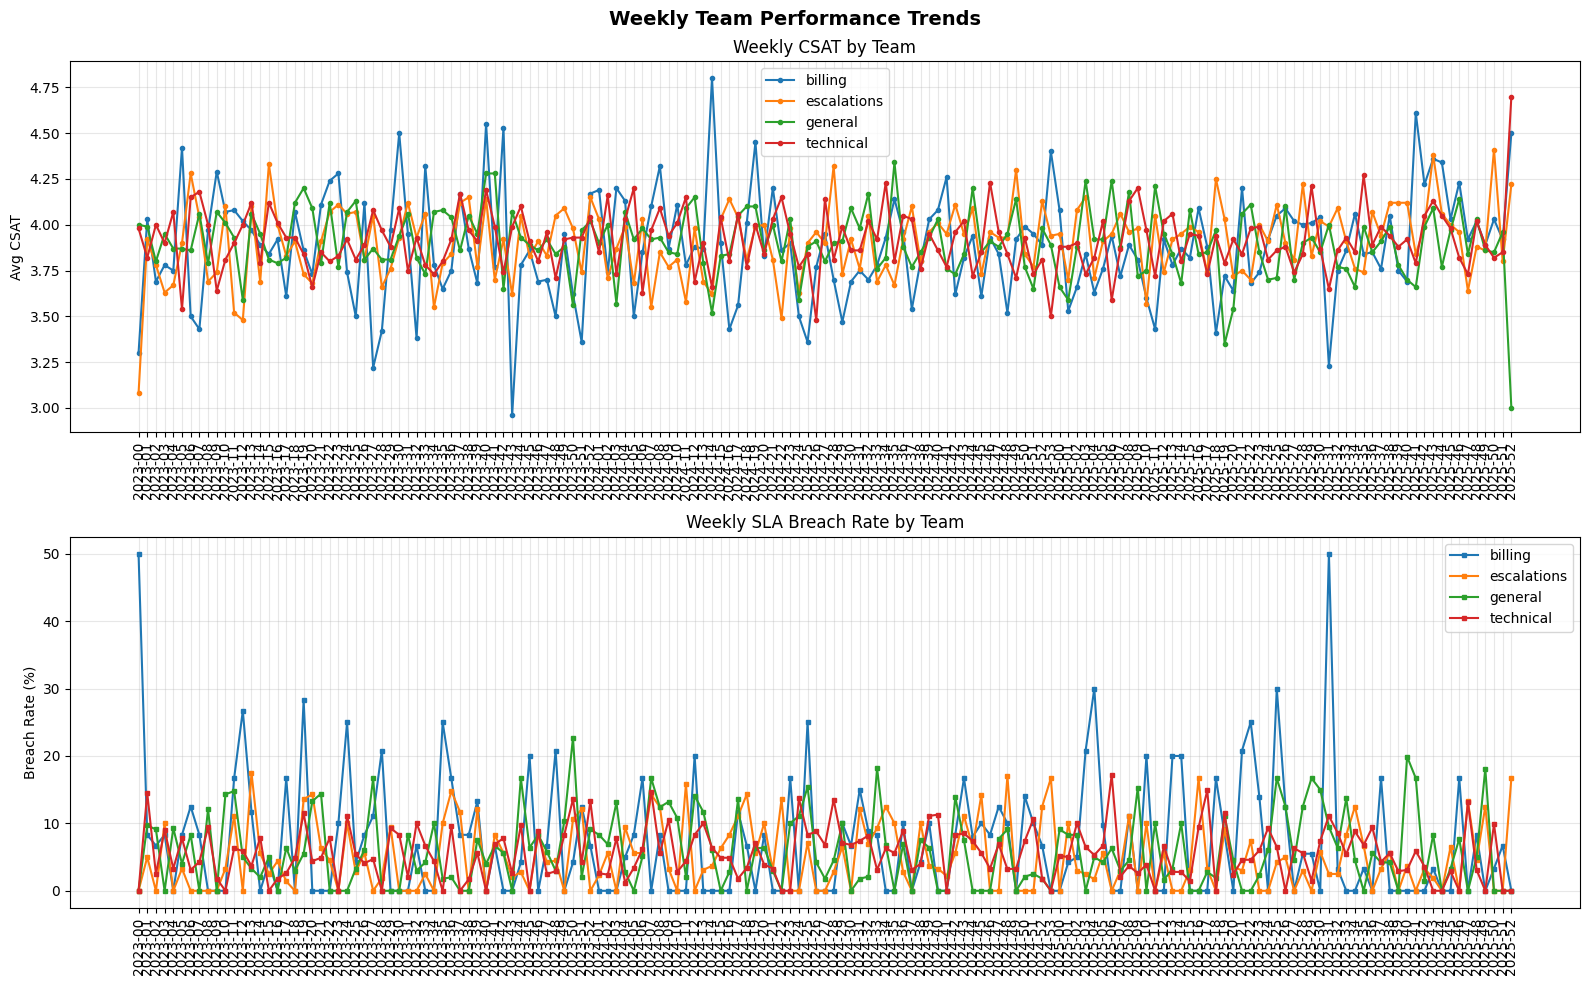

In [20]:
weekly_trend = query(f"""
select
    ticket_week,
    assigned_team,
    sum(tickets_resolved) as tickets_resolved,
    round(avg(avg_csat_score), 2) as avg_csat,
    round(avg(sla_breach_rate), 1) as breach_rate
from `{PROJECT}.{DATASET}.fct_agent_performance`
where assigned_team is not null
group by 1, 2
order by 1, 2
""")

pivot_csat = weekly_trend.pivot(
    index='ticket_week',
    columns='assigned_team',
    values='avg_csat'
)

pivot_breach = weekly_trend.pivot(
    index='ticket_week',
    columns='assigned_team',
    values='breach_rate'
)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Weekly Team Performance Trends', fontsize=14, fontweight='bold')

for team in pivot_csat.columns:
    axes[0].plot(pivot_csat.index, pivot_csat[team],
                 label=team, linewidth=1.5, marker='o', markersize=3)
axes[0].set_title('Weekly CSAT by Team')
axes[0].set_ylabel('Avg CSAT')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(True, alpha=0.3)

#only show every 4th week label to avoid crowding
tick_positions = range(0, len(pivot_breach.index), 4)
for team in pivot_breach.columns:
    axes[1].plot(pivot_breach.index, pivot_breach[team],
                 label=team, linewidth=1.5, marker='s', markersize=3)
axes[1].set_title('Weekly SLA Breach Rate by Team')
axes[1].set_ylabel('Breach Rate (%)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('weekly_team_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

In [21]:
print("=" * 55)
print('AGENT PERFORMANCE - KEY FINDINGS')
print("=" * 55)

best_team = team_perf.loc[team_perf['avg_csat'].idxmax(), 'assigned_team']
worst_team = team_perf.loc[team_perf['avg_breach_rate'].idxmax(), 'assigned_team']
best_level = level_perf.loc[level_perf['avg_csat'].idxmax(), 'agent_level']

print(f"\nHighest CSAT team: {best_team}")
print(f"Highest breach team: {worst_team}")
print(f"Best performing level: {best_level}")

senior = level_perf[level_perf['agent_level'] == 'senior']
junior = level_perf[level_perf['agent_level'] == 'junior']
if len(senior) and len(junior):
    csat_diff = senior['avg_csat'].values[0] - junior['avg_csat'].values[0]
    breach_diff = junior['avg_breach_rate'].values[0] - senior['avg_breach_rate'].values[0]
    print(f"\nSenior vs Junior CSAT gap: +{csat_diff:.2f} points")
    print(f"Senior vs Junior breach rate gap: -{breach_diff:.1f}%")

print("=" * 55)

AGENT PERFORMANCE - KEY FINDINGS

Highest CSAT team: escalations
Highest breach team: billing
Best performing level: senior

Senior vs Junior CSAT gap: +0.08 points
Senior vs Junior breach rate gap: -8.6%


**By Level:**
- Senior agents have an 8.6% lower SLA breach rate than junior agents
- CSAT gap between senior and junior agents is modest (+0.08 points), suggesting that once a ticket is handled, agent level matter less for satisfaction than whether the SLA was met
- The bigger leve is breach rate, not CSAT coaching </br>

**By team:**
- Billing has the highest breach rate, likely driven by the complexity of billing disputes requiring back-and-forth with finance teams
- Escalations has the highest CSAT: counterintuitive but explainable: by the team a ticket reaches escalations, customer expectations have been reset and the senior agents handling escalations over-deliver </br>

**Business implications:**
1. Focus SLA improvement efforts on the billing team specifically
2. Junior agent coaching should prioritize response time over soft skills
3. The escalations team's approach to expectation-setting may be worth replicating across other teams </br>

**Next Steps:** Can we predict which tickets will escalate before they do? -> See `ml/01_ticket_classifier.ipynb`